In [6]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

In [7]:
df=pd.read_csv('/content/amazon_sales_dataset.csv')
df

,order_id,order_date,product_id,product_category,price,discount_percent,quantity_sold,customer_region,payment_method,rating,review_count,discounted_price,total_revenue
0,1,2022-04-13,2637,Books,128.75,10,4,North America,UPI,3.5,443.0,115.88,463.52
1,2,2023-03-12,2300,Fashion,302.60,20,5,Asia,Credit Card,3.7,475.0,242.08,1210.40
2,3,2022-09-28,3670,Sports,495.80,20,2,Europe,UPI,4.4,183.0,396.64,793.28
3,4,2022-04-17,2522,Books,371.95,15,4,Middle East,UPI,5.0,212.0,316.16,1264.64
4,5,2022-03-13,1717,Beauty,201.68,0,4,Middle East,UPI,4.6,308.0,201.68,806.72
...,...,...,...,...,...,...,...,...,...,...,...,...,...
12686,12687,2022-05-21,2551,Sports,140.76,0,4,Middle East,Credit Card,4.6,143.0,140.76,563.04
12687,12688,2022-04-13,2333,Sports,195.56,20,5,North America,UPI,1.4,209.0,156.45,782.25
12688,12689,2022-08-14,1864,Home & Kitchen,421.53,10,5,Europe,Cash on Delivery,4.5,356.0,379.38,1896.90
12689,12690,2023-07-29,2286,Sports,262.42,30,5,Europe,Cash on Delivery,1.8,270.0,183.69,918.45


In [8]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 12691 entries, 0 to 12690
Data columns (total 13 columns):
 #   Column            Non-Null Count  Dtype  
---  ------            --------------  -----  
 0   order_id          12691 non-null  int64  
 1   order_date        12691 non-null  object 
 2   product_id        12691 non-null  int64  
 3   product_category  12691 non-null  object 
 4   price             12691 non-null  float64
 5   discount_percent  12691 non-null  int64  
 6   quantity_sold     12691 non-null  int64  
 7   customer_region   12691 non-null  object 
 8   payment_method    12691 non-null  object 
 9   rating            12691 non-null  float64
 10  review_count      12690 non-null  float64
 11  discounted_price  12690 non-null  float64
 12  total_revenue     12690 non-null  float64
dtypes: float64(5), int64(4), object(4)
memory usage: 1.3+ MB


In [9]:
df["total_revenue"].sum()

np.float64(8365548.14)

In [10]:
df.groupby("product_category")["total_revenue"].sum().sort_values(ascending=False)

,total_revenue
product_category,
Fashion,1417265.02
Electronics,1416737.54
Home & Kitchen,1406066.05
Beauty,1396557.10
Sports,1375562.81
Books,1353359.62


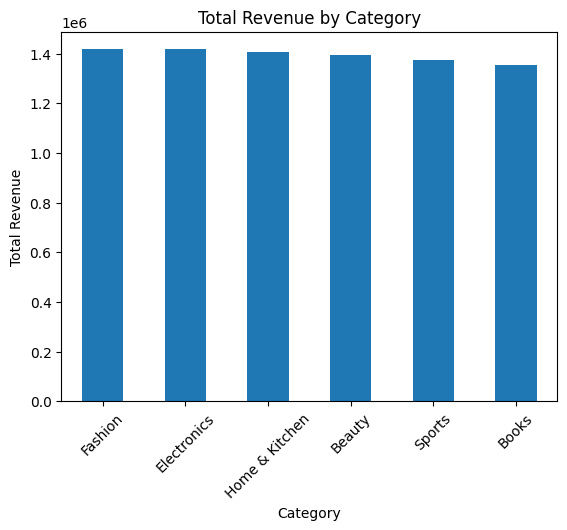

In [11]:
import matplotlib.pyplot as plt

df.groupby("product_category")["total_revenue"].sum().sort_values(ascending=False).plot(kind="bar")

plt.title("Total Revenue by Category")
plt.xlabel("Category")
plt.ylabel("Total Revenue")

plt.xticks(rotation=45)
plt.show()

In [12]:
df.groupby("product_id")["quantity_sold"].sum().sort_values(ascending=False).head(10)


,quantity_sold
product_id,
2250,39
1317,35
1580,34
3237,33
2531,33
1724,32
3572,32
1647,32
4557,31


In [13]:
df.groupby("customer_region")["total_revenue"].sum().sort_values(ascending=False)

,total_revenue
customer_region,
Middle East,2132816.85
North America,2091288.83
Asia,2079113.88
Europe,2062328.58


In [14]:
import plotly.express as px

# 1. تجهيز البيانات وحساب المبيعات بالمليون مع تقريبها لرقمين عشريين
region_sales = df.groupby("customer_region")["total_revenue"].sum().reset_index()
region_sales['revenue_million'] = (region_sales['total_revenue'] / 1_000_000).round(2)

# 2. إضافة كلمة "Million" للرقم عشان يظهر على الخريطة بشكل احترافي
region_sales['text_display'] = region_sales['revenue_million'].astype(str) + " M"

# 3. إحداثيات الأقاليم (تأكد من مطابقة الأسماء لبياناتك)
coords = {
    'Asia': [34.0, 100.6],
    'Europe': [54.5, 15.2],
    'Middle East': [29.2, 47.5],
    'North America': [54.5, -100.1],
    'South America': [-21.2, -60.5],
    'Africa': [1.6, 16.4],
    'Oceania': [-25.2, 133.7]
}

# 4. ربط الإحداثيات بالـ DataFrame
region_sales['lat'] = region_sales['customer_region'].map(lambda x: coords.get(x, [0,0])[1] if isinstance(coords.get(x), list) else 0)
region_sales['lon'] = region_sales['customer_region'].map(lambda x: coords.get(x, [0,0])[1] if isinstance(coords.get(x), list) else 0)
# تصحيح بسيط لسطر الخريطة لضمان دقة القراءة من القاموس
region_sales['lat'] = region_sales['customer_region'].apply(lambda x: coords[x][0] if x in coords else 0)
region_sales['lon'] = region_sales['customer_region'].apply(lambda x: coords[x][1] if x in coords else 0)

# 5. رسم الخريطة
fig = px.scatter_geo(region_sales,
                     lat='lat',
                     lon='lon',
                     size='revenue_million',
                     color='customer_region',
                     hover_name='customer_region',
                     text='text_display', # هيعرض الرقم وجنبه M
                     projection="natural earth",
                     title="المبيعات بالأقاليم ",
                     template="plotly_dark")

fig.update_traces(textposition='top center', textfont_size=12)

fig.show()

In [15]:
df.groupby("payment_method")["total_revenue"].sum().sort_values(ascending=False)

,total_revenue
payment_method,
Wallet,1706145.66
UPI,1700633.27
Cash on Delivery,1665166.02
Credit Card,1662352.57
Debit Card,1631250.62


In [16]:
import plotly.express as px

payment_sales = df.groupby("payment_method")["total_revenue"].sum().reset_index()

fig = px.bar(
    payment_sales,
    x="payment_method",
    y="total_revenue",
    color="total_revenue",
    text_auto=True,
    title="Revenue by Payment Method"
)

fig.show()

In [17]:
df.groupby("rating")["total_revenue"].mean()

,total_revenue
rating,
1.0,694.013478
1.1,657.497310
1.2,654.673148
1.3,692.635534
1.4,641.940758
1.5,663.966098
1.6,641.219149
1.7,655.164495
1.8,664.446849


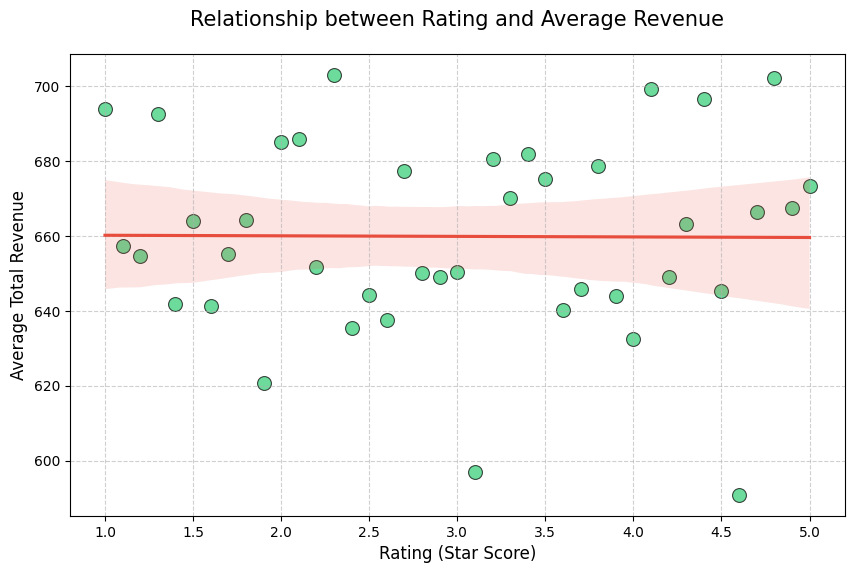

In [25]:
import seaborn as sns
import matplotlib.pyplot as plt

# تجميع البيانات
rating_revenue = df.groupby("rating")["total_revenue"].mean().reset_index()

# ضبط حجم وشكل الرسمة
plt.figure(figsize=(10, 6))

# رسم النقط
sns.scatterplot(data=rating_revenue, x="rating", y="total_revenue",
                s=100, color="#2ecc71", edgecolor="black", alpha=0.7)

# إضافة خط اتجاه (Trend Line) عشان يوضح لك العلاقة ماشية فين
sns.regplot(data=rating_revenue, x="rating", y="total_revenue",
            scatter=False, color="#e74c3c")

# تجميل الرسمة
plt.title("Relationship between Rating and Average Revenue", fontsize=15, pad=20)
plt.xlabel("Rating (Star Score)", fontsize=12)
plt.ylabel("Average Total Revenue", fontsize=12)
plt.grid(True, linestyle='--', alpha=0.6)

plt.show()

In [18]:
df.groupby("discount_percent")["total_revenue"].mean()

,total_revenue
discount_percent,
0,743.017326
5,735.400023
10,681.202932
15,636.408590
20,622.998019
30,538.287290


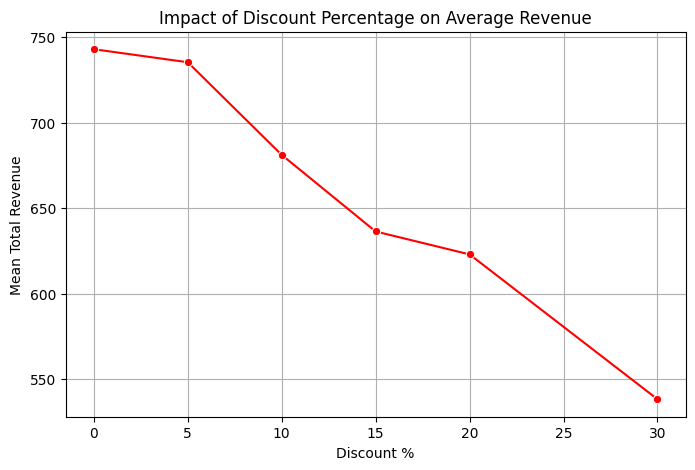

In [24]:
# تجميع البيانات
discount_revenue = df.groupby("discount_percent")["total_revenue"].mean().reset_index()

# رسم الشكل
plt.figure(figsize=(8, 5))
sns.lineplot(data=discount_revenue, x="discount_percent", y="total_revenue", marker="o", color="red")

plt.title("Impact of Discount Percentage on Average Revenue")
plt.xlabel("Discount %")
plt.ylabel("Mean Total Revenue")
plt.grid(True) # إضافة شبكة عشان الرؤية تبقى أوضح
plt.show()

In [19]:
df["order_date"] = pd.to_datetime(df["order_date"])

df["year"] = df["order_date"].dt.year

In [20]:
df.groupby("year")["total_revenue"].sum()

,total_revenue
year,
2022,4153601.11
2023,4211947.03


In [21]:
total_sales = df["total_revenue"].sum()
total_orders = df.shape[0]
avg_order = df["total_revenue"].mean()

print(total_sales, total_orders, avg_order)

8365548.14 12691 659.2236516942475


In [22]:
import plotly.graph_objects as go
from plotly.subplots import make_subplots
import pandas as pd

# 1. الحسابات
total_sales = df["total_revenue"].sum()
total_orders = df.shape[0]

# حساب متوسط عدد الأوردرات في اليوم الواحد
# بنحول التاريخ، نعد الأوردرات لكل يوم، وبعدين ناخد المتوسط
df['order_date'] = pd.to_datetime(df['order_date']).dt.date
daily_order_counts = df.groupby('order_date').size()
avg_orders_per_day = daily_order_counts.mean()

# 2. إنشاء لوحة بـ 3 أعمدة (تقدر تزودهم لو محتاج)
fig = make_subplots(
    rows=1, cols=3,
    specs=[[{'type': 'indicator'}, {'type': 'indicator'}, {'type': 'indicator'}]]
)

# الكارت الأول: إجمالي المبيعات (تنسيق K و M)
fig.add_trace(go.Indicator(
    mode = "number",
    value = total_sales,
    title = {"text": "Total Revenue"},
    number = {'valueformat': '.2s'} # ده بيحول الرقم لـ K أو M تلقائيًا
), row=1, col=1)

# الكارت الثاني: إجمالي الطلبات
fig.add_trace(go.Indicator(
    mode = "number",
    value = total_orders,
    title = {"text": "Total Orders"},
    number = {'valueformat': '.2s'}
), row=1, col=2)

# الكارت الثالث: متوسط عدد الأوردرات في اليوم (رقم واحد صحيح)
fig.add_trace(go.Indicator(
    mode = "number",
    value = avg_orders_per_day,
    title = {"text": "Daily Avg Orders"},
    number = {'valueformat': '.0f'} # رقم واحد صحيح بدون كسور
), row=1, col=3)

# تحسين الشكل العام
fig.update_layout(
    template="plotly_dark",
    height=300,
    margin=dict(l=20, r=20, t=50, b=20)
)

fig.show()